In [1]:
import uproot
import pandas as pd


important_variables = ['mcnhits', 'mcPEWavelength','mcpecount','mcparticlecount']

In [3]:
#10_000 photons and 100 events (One million photons) polished setup
with uproot.open("/home/silver/PTPSim/output.ntuple.root") as file:
    print(file.keys())
    tree =  file["output"]
    tree_meta = file["meta"]
    df = tree.arrays(library="pd")
    df_meta = tree_meta.arrays(library="pd")

['meta;1', 'output;1']


In [4]:
valeurs_unique_sipm_ID = []
for nbr in df_meta['pmtId'][0]:
    if nbr not in valeurs_unique_sipm_ID:
        valeurs_unique_sipm_ID.append(int(nbr))
print(valeurs_unique_sipm_ID)
print(len(valeurs_unique_sipm_ID))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
60


In [5]:
valeurs_unique_sipm_ID_too = []
for i in range(len(df["mcPEPMTID"])):
    for nbr in df["mcPEPMTID"][i]:    
        if nbr not in valeurs_unique_sipm_ID_too:
            valeurs_unique_sipm_ID_too.append(int(nbr))
valeurs_unique_sipm_ID_too.sort()
print(valeurs_unique_sipm_ID_too)
print(len(valeurs_unique_sipm_ID_too))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
60


In [6]:
from collections import Counter
liste_plat = [int(element) for sous_liste in df["mcPEPMTID"] for element in sous_liste]
liste_plat.sort()
dict_for_plot = dict(Counter(liste_plat))

In [7]:
print(dict_for_plot)

{0: 255, 1: 200, 2: 196, 3: 189, 4: 155, 5: 169, 6: 158, 7: 150, 8: 140, 9: 148, 10: 151, 11: 130, 12: 133, 13: 154, 14: 159, 15: 123, 16: 163, 17: 164, 18: 156, 19: 151, 20: 151, 21: 136, 22: 133, 23: 132, 24: 133, 25: 141, 26: 146, 27: 173, 28: 278, 29: 293, 30: 342, 31: 347, 32: 262, 33: 218, 34: 212, 35: 220, 36: 204, 37: 170, 38: 186, 39: 158, 40: 163, 41: 135, 42: 118, 43: 159, 44: 159, 45: 148, 46: 202, 47: 201, 48: 164, 49: 188, 50: 177, 51: 195, 52: 188, 53: 180, 54: 151, 55: 159, 56: 159, 57: 210, 58: 305, 59: 460}


In [8]:
df["mcPEPMTID"]

0     [16, 19, 52, 21, 9, 14, 12, 12, 0, 43, 43, 56,...
1     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2     [38, 38, 38, 38, 38, 33, 33, 33, 33, 33, 33, 3...
3     [58, 58, 39, 21, 21, 17, 17, 17, 12, 15, 8, 8,...
4     [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 3...
                            ...                        
95    [54, 42, 42, 3, 3, 6, 48, 48, 48, 53, 53, 8, 8...
96    [48, 30, 30, 30, 8, 58, 58, 58, 58, 58, 32, 32...
97    [39, 39, 43, 43, 43, 11, 11, 11, 18, 18, 18, 1...
98    [40, 2, 2, 2, 2, 2, 2, 2, 2, 31, 31, 31, 31, 3...
99    [37, 37, 37, 37, 19, 19, 19, 19, 46, 46, 11, 1...
Name: mcPEPMTID, Length: 100, dtype: awkward

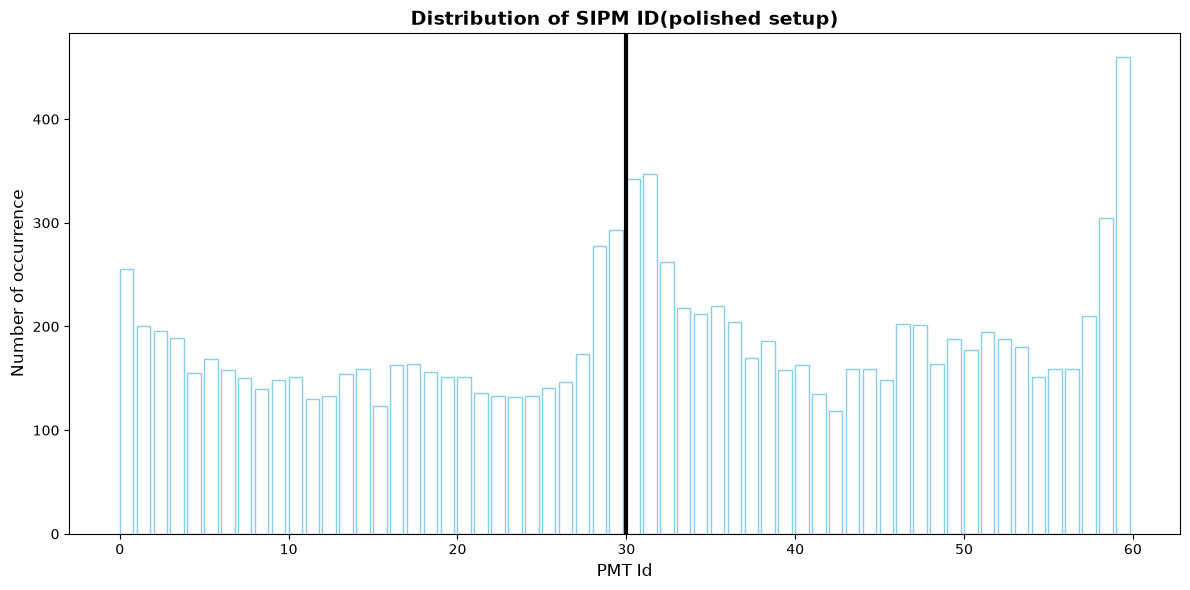

In [27]:
import matplotlib.pyplot as plt

# 1. Configurer la taille du graphique
plt.figure(figsize=(12, 6))

# 2. Dessiner le diagramme en barres
plt.bar(
    list(dict_for_plot.keys()),
    list(dict_for_plot.values()),
    color="white",
    edgecolor="skyblue",
    align="edge",
)
plt.axvline(x=30, color='black', linewidth=3, linestyle='-')
# 4. Personnaliser les titres et les axes
plt.title(
    "Distribution of SIPM ID(polished setup)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("PMT Id", fontsize=12)
plt.ylabel("Number of occurrence", fontsize=12)

# Évite que les étiquettes du bas ou des côtés soient coupées
plt.tight_layout()

# 6. Afficher le graphique
plt.show()


In [10]:
#efficiency
sum_mcnhist = 0
sum_nb_wvlght = 0
sum_mcpecount = 0
sum_all_PE_treated = 0
for j in range(len(df[important_variables[0]])):
    sum_mcnhist = sum_mcnhist + df[important_variables[0]][j]
    sum_nb_wvlght = sum_nb_wvlght +len(df[important_variables[1]][j])
    sum_mcpecount = sum_mcpecount + df[important_variables[2]][j]
    sum_all_PE_treated = sum_all_PE_treated + df['mcparticlecount'][j]
print(f'There was {sum_mcnhist} total values in mcnhits and there was {sum_nb_wvlght} values in the wavelentgh, and has {sum_mcpecount} mcpacount  over {sum_all_PE_treated} in total')
print(f'So the efficiency may be {(sum_mcpecount*100)/sum_all_PE_treated}%')

There was 3752 total values in mcnhits and there was 11100 values in the wavelentgh, and has 11100 mcpacount  over 1000000 in total
So the efficiency may be 1.11%


In [11]:
df['mcPEPMTID']

0     [16, 19, 52, 21, 9, 14, 12, 12, 0, 43, 43, 56,...
1     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2     [38, 38, 38, 38, 38, 33, 33, 33, 33, 33, 33, 3...
3     [58, 58, 39, 21, 21, 17, 17, 17, 12, 15, 8, 8,...
4     [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 3...
                            ...                        
95    [54, 42, 42, 3, 3, 6, 48, 48, 48, 53, 53, 8, 8...
96    [48, 30, 30, 30, 8, 58, 58, 58, 58, 58, 32, 32...
97    [39, 39, 43, 43, 43, 11, 11, 11, 18, 18, 18, 1...
98    [40, 2, 2, 2, 2, 2, 2, 2, 2, 31, 31, 31, 31, 3...
99    [37, 37, 37, 37, 19, 19, 19, 19, 46, 46, 11, 1...
Name: mcPEPMTID, Length: 100, dtype: awkward

In [12]:
total_PE = df['mcparticlecount'][0]
print(total_PE)

10000


In [13]:
#plots
all_wavelenght = []
for pack_wfm in range(len(df[important_variables[1]])):
    for one_wfm in range(len(df[important_variables[1]][pack_wfm])):
        all_wavelenght.append(df[important_variables[1]][pack_wfm][one_wfm])
print(len(all_wavelenght))

11100


In [14]:
data_wvlght = pd.DataFrame(all_wavelenght, columns = ['Wavelenght'])

In [15]:
data_wvlght.describe()

,Wavelenght
count,11100.000000
mean,0.000398
std,0.000044
min,0.000293
25%,0.000365
50%,0.000394
75%,0.000430
max,0.000529


In [16]:
data_wvlght['Wavelenght'].unique()

array([0.00044556, 0.00041632, 0.00036484, ..., 0.000336  , 0.00039958,
       0.00035042], shape=(11051,))

In [17]:
data_wvlght['Wavelenght'].nunique()

11051

In [18]:
data_wvlght["Intervalle_Num"] = (
    data_wvlght['Wavelenght'] // 0.000005
) * 5

In [19]:
data_wvlght.head()

,Wavelenght,Intervalle_Num
0,0.000446,445.0
1,0.000416,415.0
2,0.000365,360.0
3,0.000448,445.0
4,0.000449,445.0


In [20]:
for_plot = pd.DataFrame(
    {"Wavelenght": sorted(data_wvlght["Intervalle_Num"].unique())}
)

In [21]:
for_plot = pd.DataFrame(
    {"Wavelenght": sorted(data_wvlght["Intervalle_Num"].unique())}
)

In [22]:
len(for_plot['Wavelenght'])

48

In [23]:
for_plot = (
    data_wvlght["Intervalle_Num"]
    .value_counts()
    .reset_index(name="Compte")
)

In [24]:
for_plot.head()

,Intervalle_Num,Compte
0,395.0,542
1,385.0,534
2,415.0,530
3,390.0,528
4,380.0,496


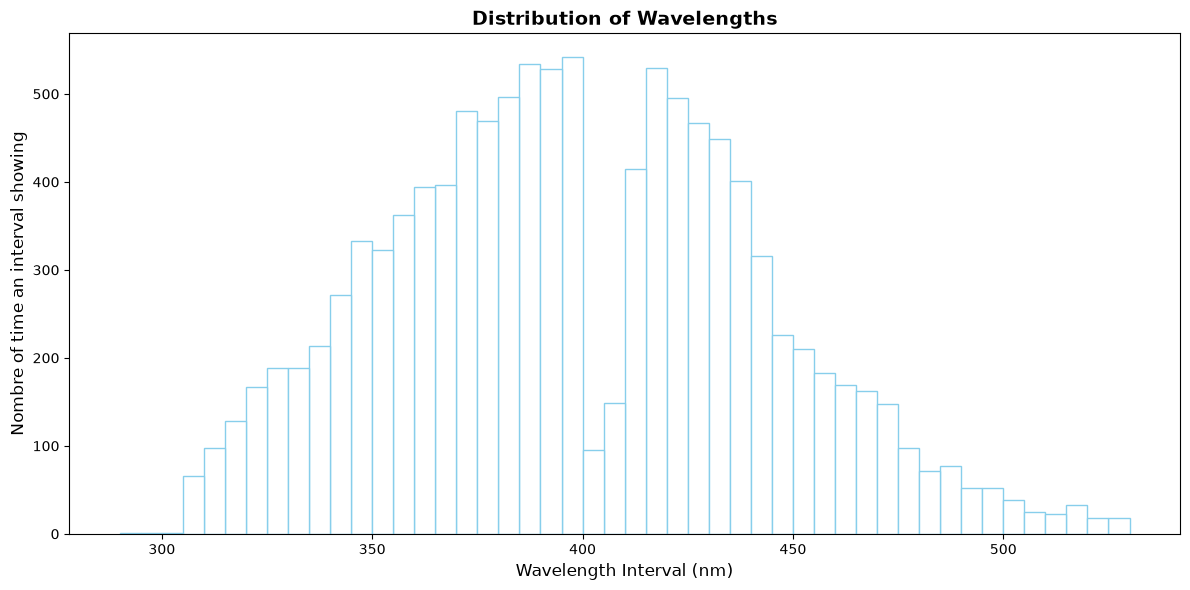

In [25]:
import matplotlib.pyplot as plt

# 1. Configurer la taille du graphique
plt.figure(figsize=(12, 6))

# 2. Dessiner le diagramme en barres
# width=0.0000045 permet de laisser un tout petit espace noir entre les barres pour le style
plt.bar(
    for_plot["Intervalle_Num"],
    for_plot["Compte"],
    width=5,
    color="white",
    edgecolor="skyblue",
    align="edge",
)

# 4. Personnaliser les titres et les axes
plt.title(
    "Distribution of Wavelengths",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Wavelength Interval (nm)", fontsize=12)
plt.ylabel("Nombre of time an interval showing", fontsize=12)

# Évite que les étiquettes du bas ou des côtés soient coupées
plt.tight_layout()

# 6. Afficher le graphique
plt.show()


In [26]:
print(for_plot.columns)


Index(['Intervalle_Num', 'Compte'], dtype='str')
